# Lab 7.05 - Time series analysis

In [1]:
# Package imports
import numpy as np                                  # Scientific computing
import scipy.stats as stats                         # Statistical tests
import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation
from sklearn.linear_model import LinearRegression   # Linear regression model

# Time series analysis
from datetime import datetime
from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

### Exercise 5 - Alcoholic beverages sales

The file US Retail.csv contains monthly retail sales of beer, wine, and liquor at U.S. liquor stores.

- Is seasonality present in these data?
- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Split the dataset in a train (1992-01-01 up to and including 2008-12-01) and test set (2009-01-01 up to and including 2009-12-01)  
- Create and train the model. 
- Predict the values for 2009.
- Create a plot with the train data, the fitted values, the test data and the predicted values.
- Calculate MAE

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/US%20Retail.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

,Total Sales
Month,
1992-01-01,1519
1992-02-01,1551
1992-03-01,1606
1992-04-01,1686
1992-05-01,1834


<Axes: xlabel='Month'>

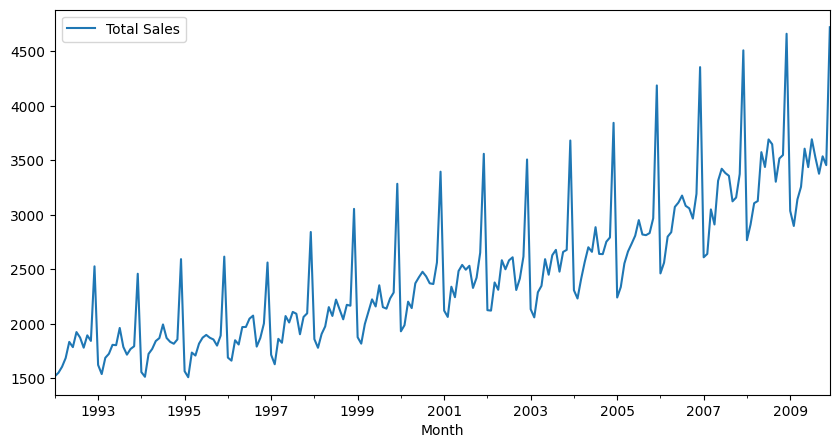

In [3]:
data.plot(y='Total Sales', figsize=(10, 5))

In [4]:
train = data[:'2008-12-01']
test = data['2009-01-01':]

data_tes = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12, freq='MS').fit()

In [6]:
data_tes_fcast = data_tes.forecast(12)
data_tes_fcast.head(12)

2009-01-01    2995.959539
2009-02-01    3117.438920
2009-03-01    3354.298326
2009-04-01    3360.812343
2009-05-01    3775.107630
2009-06-01    3678.437206
2009-07-01    3863.198406
2009-08-01    3776.502243
2009-09-01    3451.260772
2009-10-01    3617.490709
2009-11-01    3680.234549
2009-12-01    4884.260034
Freq: MS, dtype: float64

In [ ]:
data['Total Sales'].plot(legend=True, figsize=(10, 5))
data_tes_fcast.plot(marker='.', legend=True, label='Forecast TES')

In [8]:
season = data_tes.season.iloc[-12:].values

y_pred = [
    data_tes.level.iloc[-13] + data_tes.trend.iloc[-13] * k +
    season[k - 1] for k in range(1, 13)
]

mean_absolute_error(test, y_pred)

84.42615654549293

## Source
Business Analytics Data Analysis & Decision Making 